<a href="https://colab.research.google.com/github/dhag/colab_test/blob/main/StableDiffusionControlNetPipeline_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# お手本の画像をまねて絵を描かせる（StableDiffusion + ControlNet）
StableDiffusionPipeline_.ipynb の続き。

文章（プロンプト）だけで絵を描かせると、ポーズや構図は思い通りになりにくい。
このノートブックでは、**お手本の画像**から「ポーズ」「形（輪郭線）」「立体感・配置」などだけを取り出して、その通りに新しい絵を描かせる。
絵柄や服装・髪型などはプロンプトで決める。

選べること（「4. やりたいことを選ぶ」で番号で選ぶ）：
1. ポーズをまねる：お手本の人と同じ姿勢で描く
2. 形・線をまねる：輪郭線はそのままで絵柄を変える
3. 立体感・配置をまねる：手前と奥の位置関係を保って描く
4. 見た目を保って描き直す：元の絵に近いまま描き直す

お手本の画像は、最初はサンプル画像を使う。自分の画像も使える。

（この仕組みを ControlNet（コントロールネット）という。）

モデル・お手本の画像などはすべて実行時にダウンロードするので、Google Drive は使わない。
（ランタイムを切ると消える。もう一度実行すれば再ダウンロードされる）

参考：SDXL 版の元になった記事 https://zenn.dev/asap/articles/c08dffa41bec03

ランタイムのタイプをGPUにしておくこと。

1. 環境のセットアップ

In [1]:
!pip install diffusers transformers accelerate peft safetensors controlnet-aux
# Colab に入っている古い torchao（0.10.0 など）が残っていると、peft が LoRA 読み込み時に ImportError を出す。
# peft は torchao が「無ければ使わない」、「古いのがあればエラー」という判定なので、このノートブックでは使わない torchao を削除しておく。
!pip uninstall -y torchao
# controlnet_aux は import 時に、使わない前処理（MediapipeFaceDetector）まで読み込む。
# その中で mediapipe の古い機能（mp.solutions）を使っているが、mediapipe 0.10.31 以降にはそれが無いので import が AttributeError になる。
# controlnet_aux は mediapipe が「無ければその前処理を無効にして続行」する作りなので、このノートブックでは使わない mediapipe を削除しておく。
!pip uninstall -y mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 6.6 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


2. ファイルのダウンローダ（StableDiffusionPipeline_.ipynb と同じ）。プレイボタンだけ押して次へすすんで

In [2]:
import os
import requests
from tqdm import tqdm
from urllib.parse import unquote
import re
"""
# ファイルをダウンロードするだけの関数

# 使用例
if __name__ == "__main__":
    url = 'https://civitai.com/api/download/models/90854'
    path = './'

    # レジューム機能有効（デフォルト）
    download_model(url, path, use_original_filename=True, enable_resume=True)

    # レジューム機能無効（完全再ダウンロード）
    # download_model(url, path, use_original_filename=True, enable_resume=False)

# wgwt,cURLといったやり方があるが、デカいので別途関数を用意しただけ。
!wget https://example.com/file.pt
!curl -O https://civitai.com/api/download/models/90854
"""
def download_model(url, path='', use_original_filename=False, enable_resume=True):
    if path == '' or not os.path.exists(path):
        path = './'
    if not os.path.exists(path):
        os.makedirs(path)

    print("ファイル情報を確認中...")

    # HEADリクエストでファイル情報を取得
    try:
        head_response = requests.head(url, allow_redirects=True)
        head_response.raise_for_status()
        remote_size = int(head_response.headers.get('content-length', 0))
        supports_range = head_response.headers.get('accept-ranges') == 'bytes'
    except:
        # HEADが失敗した場合はGETで取得
        remote_size = 0
        supports_range = False

    # GETリクエストを開始してファイル名を取得
    headers = {}
    resume_pos = 0

    with requests.get(url, stream=True, headers=headers) as r:
        r.raise_for_status()

        # リモートファイルサイズを取得（HEADで取得できなかった場合）
        if remote_size == 0:
            remote_size = int(r.headers.get('content-length', 0))
            supports_range = r.headers.get('accept-ranges') == 'bytes'

        # ファイル名の取得
        filename = None

        if use_original_filename:
            # まずContent-Dispositionヘッダーからファイル名を取得を試みる
            content_disposition = r.headers.get('content-disposition')
            if content_disposition:
                # filename*=UTF-8''... 形式の処理
                match = re.search(r"filename\*=UTF-8''([^;]+)", content_disposition)
                if match:
                    filename = unquote(match.group(1))
                else:
                    # 通常のfilename="..." 形式の処理
                    match = re.search(r'filename="([^"]+)"', content_disposition)
                    if match:
                        filename = match.group(1)
                    else:
                        # filename=... 形式（クォートなし）の処理
                        match = re.search(r'filename=([^;]+)', content_disposition)
                        if match:
                            filename = match.group(1).strip()

            # Content-Dispositionで取得できない場合、URLから抽出を試みる
            if not filename:
                url_filename = unquote(url.split('/')[-1])
                if '.' in url_filename:  # 拡張子がある場合のみ使用
                    filename = url_filename

        # ファイル名が取得できない場合のフォールバック
        if not filename:
            # URLの最後の部分を使用（ID番号など）
            filename = url.split('/')[-1]
            # 拡張子がない場合のデフォルト処理
            if '.' not in filename:
                # Content-Typeから拡張子を推測
                content_type = r.headers.get('content-type', '')
                if 'application/octet-stream' in content_type or 'civitai.com' in url:
                    filename += '.safetensors'  # CivitAI等のML modelサイト
                elif 'image' in content_type:
                    filename += '.jpg'
                elif 'video' in content_type:
                    filename += '.mp4'
                elif 'audio' in content_type:
                    filename += '.mp3'
                else:
                    filename += '.bin'  # 汎用バイナリファイル

        # 保存パス
        filepath = os.path.join(path, filename)

        # ファイルの存在確認とサイズチェック
        if os.path.exists(filepath):
            local_size = os.path.getsize(filepath)

            if remote_size > 0:
                if local_size == remote_size:
                    print(f"✅ ファイルが既に存在し、サイズが一致します: {filepath}")
                    print(f"   ローカル: {local_size:,} bytes")
                    print(f"   リモート: {remote_size:,} bytes")
                    print("ダウンロードをスキップします")
                    return filepath
                elif local_size > remote_size:
                    print(f"⚠️  ローカルファイルのサイズが大きすぎます: {filepath}")
                    print(f"   ローカル: {local_size:,} bytes > リモート: {remote_size:,} bytes")
                    print("ファイルを削除して再ダウンロードします")
                    os.remove(filepath)
                elif local_size < remote_size and enable_resume and supports_range:
                    print(f"🔄 部分的にダウンロード済み: {filepath}")
                    print(f"   ローカル: {local_size:,} bytes / リモート: {remote_size:,} bytes")
                    print(f"   進捗: {local_size/remote_size*100:.1f}%")
                    print("レジューム機能を使用してダウンロードを続行します")
                    resume_pos = local_size
                else:
                    print(f"⚠️  ローカルファイルのサイズが不一致です: {filepath}")
                    print(f"   ローカル: {local_size:,} bytes < リモート: {remote_size:,} bytes")
                    if not supports_range:
                        print("   サーバーがレジューム機能に対応していません")
                    print("ファイルを削除して再ダウンロードします")
                    os.remove(filepath)
            else:
                print(f"⚠️  リモートファイルサイズが取得できません: {filepath}")
                print(f"   ローカルファイル（{local_size:,} bytes）が存在します")
                print("サイズ比較ができないため、既存ファイルを使用します")
                return filepath

    # レジュームの場合は新しいリクエストを作成
    if resume_pos > 0:
        headers['Range'] = f'bytes={resume_pos}-'
        print(f"レジューム位置: {resume_pos:,} bytes から再開")

    with requests.get(url, stream=True, headers=headers) as r:
        r.raise_for_status()

        # レジューム時のステータスコード確認
        if resume_pos > 0 and r.status_code != 206:
            print("⚠️  サーバーがレンジリクエストに対応していません。最初からダウンロードします")
            resume_pos = 0
            # レンジヘッダーを削除して再リクエスト
            if 'Range' in headers:
                del headers['Range']
            r = requests.get(url, stream=True, headers=headers)
            r.raise_for_status()

        print(f"保存先: {filepath}")

        # ダウンロード情報の表示
        if remote_size > 0:
            remaining_size = remote_size - resume_pos
            print(f"ファイルサイズ: {remote_size:,} bytes ({remote_size/1024/1024:.1f} MB)")
            if resume_pos > 0:
                print(f"ダウンロード済み: {resume_pos:,} bytes")
                print(f"残りサイズ: {remaining_size:,} bytes")

        print("ダウンロード中...")

        # ファイルのオープンモード設定
        mode = 'ab' if resume_pos > 0 else 'wb'

        with open(filepath, mode) as f:
            # 進捗バーの設定
            if remote_size > 0:
                initial = resume_pos
                total = remote_size
            else:
                initial = 0
                total = None

            # tqdmを使用して進捗バーを表示しながらファイルに書き込む
            with tqdm(
                initial=initial,
                total=total,
                unit='B',
                unit_scale=True,
                desc=filename
            ) as pbar:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
                    pbar.update(len(chunk))

    # 最終確認
    if remote_size > 0:
        final_size = os.path.getsize(filepath)
        if final_size == remote_size:
            print(f"✅ ダウンロード完了: {filepath}")
            print(f"   ファイルサイズ: {final_size:,} bytes")
        else:
            print(f"⚠️  ダウンロード完了しましたが、サイズが一致しません: {filepath}")
            print(f"   期待値: {remote_size:,} bytes")
            print(f"   実際値: {final_size:,} bytes")
    else:
        print(f"✅ ダウンロード完了: {filepath}")

    return filepath

3. 関数の定義。プレイボタンだけ押して次へすすんで

* load_pipeline：ベースモデル・ControlNet・LoRA を読み込んでパイプラインを作る
* prepare_control_image：参照画像から ControlNet に入れる画像（骨格・輪郭・奥行きなど）を作る
* generate_image：画像を生成する

ControlNet 付きの生成には StableDiffusionControlNetPipeline を使う。StableDiffusionPipeline に ControlNet を足したもので、UNet・VAE・テキストエンコーダは同じものを使う。

In [3]:
# ControlNet 版で使う関数の定義。以降のセルはここの関数を使う。
# 1. 必要なモジュールのインポート
import os, gc, time
import numpy as np
import cv2
import torch
from PIL import Image, ImageFilter, ImageOps
from IPython.display import display
from diffusers import (StableDiffusionPipeline, StableDiffusionControlNetPipeline, ControlNetModel,
                       DPMSolverMultistepScheduler, EulerAncestralDiscreteScheduler)
from diffusers.utils import load_image
from controlnet_aux.processor import Processor

# 2. デバイス確認
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用デバイス: {device}")

# モデルの保存先フォルダ、生成画像の保存先フォルダ、アップロードした参照画像の保存先フォルダ
path = './'
os.makedirs("./outputs", exist_ok=True)
os.makedirs("./refer", exist_ok=True)

# 3. control_mode と ControlNet の対応表
# 値は (Hugging Face のモデルID, variant)。SD 1.5 用の ControlNet v1.1。
# variant="fp16" は半精度版のファイルだけをダウンロードする（約0.7GB）。
# tile には半精度版のファイルが無いので None（通常版 約1.45GB をダウンロードして半精度に変換する）。
#   tile は .bin 形式のファイルしか無いので、読み込み時に「An error occurred while trying to fetch ... safetensors」と表示されるが、
#   .bin の方で読み込まれるので問題ない。
# blur / lq は「ぼかした画像」「ノイズを加えた画像」を元に描き直すもので、低解像度の画像から描き直す tile 用の ControlNet を使う。
CONTROLNET_MODELS = {
    "tile":              ("lllyasviel/control_v11f1e_sd15_tile", None),
    "blur":              ("lllyasviel/control_v11f1e_sd15_tile", None),
    "lq":                ("lllyasviel/control_v11f1e_sd15_tile", None),
    "canny":             ("lllyasviel/control_v11p_sd15_canny", "fp16"),
    "depth":             ("lllyasviel/control_v11f1p_sd15_depth", "fp16"),
    "depth_zoe":         ("lllyasviel/control_v11f1p_sd15_depth", "fp16"),
    "openpose":          ("lllyasviel/control_v11p_sd15_openpose", "fp16"),
    "openpose_face":     ("lllyasviel/control_v11p_sd15_openpose", "fp16"),
    "openpose_faceonly": ("lllyasviel/control_v11p_sd15_openpose", "fp16"),
    "openpose_full":     ("lllyasviel/control_v11p_sd15_openpose", "fp16"),
}

# 4. パイプラインのロード
def load_pipeline(model_path_or_id, control_modes=(), loras=(), scheduler="DPM",
                  use_karras_sigmas=True, algorithm_type="dpmsolver++", solver_order=2):
    """
    model_path_or_id : ローカルのモデルファイル（.safetensors / .ckpt）、またはフォルダ／Hugging Face のモデルID
    control_modes    : 使う ControlNet のモード名のリスト。空なら ControlNet なしの StableDiffusionPipeline のまま
    loras            : [{"path": LoRAファイル, "scale": 強さ, "trigger": トリガーワード}, ...]
    scheduler        : "DPM"（DPM++ 2M）または "Eulera"（Euler Ancestral）

    ※ LoRA は同じパイプラインに2回読み込むと二重に入る。設定を変えたら load_pipeline からやり直すこと。
    """
    if os.path.isfile(model_path_or_id):
        # 単一ファイル（CivitAIなどからダウンロードしたもの）
        pipe = StableDiffusionPipeline.from_single_file(model_path_or_id, torch_dtype=torch.float16)
    else:
        # フォルダ、または Hugging Face のモデルID
        pipe = StableDiffusionPipeline.from_pretrained(model_path_or_id, torch_dtype=torch.float16)

    if control_modes:
        controlnets = []
        loaded = {}  # 同じ ControlNet を使うモードが複数あっても、読み込みは1回にする
        for mode in control_modes:
            if mode not in CONTROLNET_MODELS:
                raise ValueError(f"control_mode '{mode}' は使えない。使えるのは {', '.join(CONTROLNET_MODELS)}")
            repo, variant = CONTROLNET_MODELS[mode]
            if repo not in loaded:
                loaded[repo] = ControlNetModel.from_pretrained(repo, variant=variant, torch_dtype=torch.float16)
            controlnets.append(loaded[repo])
        # UNet・VAE・テキストエンコーダはそのまま使い回して、ControlNet 付きのパイプラインに作り替える
        pipe = StableDiffusionControlNetPipeline.from_pipe(pipe, controlnet=controlnets)

    if scheduler == "DPM":
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(
            pipe.scheduler.config,
            use_karras_sigmas=use_karras_sigmas,
            algorithm_type=algorithm_type,
            solver_order=solver_order,
        )
    elif scheduler == "Eulera":
        pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    else:
        raise ValueError("scheduler は 'DPM' または 'Eulera'")

    # VRAMが足りない場合は pipe.to(device) の代わりに pipe.enable_model_cpu_offload() を使う。
    pipe.to(device)

    # LoRA は複数読み込めるように名前（lora0, lora1, ...）を付けて読み込み、それぞれの強さを set_adapters で指定する
    names, weights = [], []
    for i, lora in enumerate(loras):
        name = f"lora{i}"
        load_lora(pipe, lora["path"], adapter_name=name)
        names.append(name)
        weights.append(lora.get("scale", 1.0))
    if names:
        pipe.set_adapters(names, adapter_weights=weights)

    return pipe

# 5. 参照画像の前処理（ControlNet に入れる画像を作る）
_processors = {}
def get_processor(name):
    # 前処理用のモデル（骨格推定・奥行き推定）は読み込みが重いので、一度読み込んだものを使い回す
    if name not in _processors:
        _processors[name] = Processor(name)
    return _processors[name]

def prepare_control_image(mode, src, width, height, low_threshold=100, high_threshold=200, blur_radius=5, noise_level=30):
    """
    mode : control_mode の名前
    src  : 参照画像の URL またはファイルパス
    """
    if mode not in CONTROLNET_MODELS:
        raise ValueError(f"control_mode '{mode}' は使えない。使えるのは {', '.join(CONTROLNET_MODELS)}")

    # 縦横比を保ったまま中央を切り抜いて width×height にする（そのまま縮小すると縦横比が変わって歪む）
    image = ImageOps.fit(load_image(src).convert("RGB"), (width, height), Image.LANCZOS)

    if mode == "tile":
        control = image
    elif mode == "blur":
        control = image.filter(ImageFilter.GaussianBlur(blur_radius))
    elif mode == "lq":
        array = np.array(image).astype(np.float32) + np.random.normal(0, noise_level, (height, width, 3))
        control = Image.fromarray(np.clip(array, 0, 255).astype(np.uint8))
    elif mode == "canny":
        edges = cv2.Canny(np.array(image), low_threshold, high_threshold)
        control = Image.fromarray(np.stack([edges] * 3, axis=2))
    elif mode == "depth":
        control = get_processor("depth_midas")(image, to_pil=True)
    elif mode == "depth_zoe":
        control = get_processor("depth_zoe")(image, to_pil=True)
    else:
        # openpose / openpose_face / openpose_faceonly / openpose_full は controlnet_aux の同名の前処理を使う
        control = get_processor(mode)(image, to_pil=True)

    # 前処理用のモデルは出力サイズが変わるので、生成サイズに揃える
    return control.resize((width, height), Image.LANCZOS)

# 6. 生成途中の latent を画像にする
# SD 1.5 の latent（4チャンネル）から RGB への線形近似の係数。行が latent の各チャンネル、列が R, G, B
SD15_LATENT_RGB_FACTORS = torch.tensor([
    [ 0.3512,  0.2297,  0.3227],
    [ 0.3250,  0.4974,  0.2350],
    [-0.2829,  0.1762,  0.2721],
    [-0.2120, -0.2616, -0.7177],
])

def latents_to_image_vae(pipe, latents):
    # VAE で復元する（正確だが遅い）
    with torch.no_grad():
        images = pipe.vae.decode(latents / pipe.vae.config.scaling_factor, return_dict=False)[0]
    return pipe.image_processor.postprocess(images, output_type="pil")[0]

def latents_to_image_approx(latents):
    # 係数を掛けて足すだけで色を出す（速いが粗い。サイズは生成画像の 1/8）
    factors = SD15_LATENT_RGB_FACTORS.to(latents.device, latents.dtype)
    rgb = torch.einsum("chw,cr->rhw", latents[0], factors)          # 値の範囲はおよそ -1〜1
    array = ((rgb + 1) / 2).clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(array)

def make_latent_saver(save_latent, latent_decoder, latent_images=None):
    """
    save_latent    : "simple"   = その時点の latent をそのまま画像にする
                     "overstep" = 直前のステップからの変化がこのまま t=0 まで続くと仮定した到達点を画像にする
    latent_decoder : "vae" または "approx"
    latent_images  : リストを渡すと、保存した画像をそこにも追加する
    """
    if save_latent not in ("simple", "overstep"):
        raise ValueError("save_latent は None / 'simple' / 'overstep'")
    if latent_decoder not in ("vae", "approx"):
        raise ValueError("latent_decoder は 'vae' / 'approx'")
    stamp = time.strftime("%Y%m%d_%H%M%S")
    last = {}

    def callback(pipe, step, timestep, callback_kwargs):
        latents = callback_kwargs["latents"]
        # このコールバックは scheduler.step() の後に呼ばれる。
        # 引数の timestep は「この step で使った」タイムステップで、latents はすでに次のタイムステップの状態になっている。
        timesteps = pipe.scheduler.timesteps
        t = float(timesteps[step + 1]) if step + 1 < len(timesteps) else 0.0

        if save_latent == "overstep" and last and last["t"] > t:
            # 直前の状態 last から今の状態まで t が (last_t - t) 進んだ。同じ割合で t=0 まで進めた位置を求める
            target = last["latents"] + (latents - last["latents"]) * (last["t"] / (last["t"] - t))
        else:
            target = latents
        last["latents"], last["t"] = latents.clone(), t

        if latent_decoder == "vae":
            image = latents_to_image_vae(pipe, target)
        else:
            image = latents_to_image_approx(target)
        image.save(f"./outputs/latent_{save_latent}_{latent_decoder}_{stamp}_{step:03d}_t{int(t)}.png")
        if latent_images is not None:
            latent_images.append(image)
        return callback_kwargs

    return callback

# 7. 画像生成
def generate_image(pipe, prompt, negative_prompt="", control_images=None, controlnet_conditioning_scale=None,
                   loras=(), seed=None, steps=28, guidance_scale=7.0, width=512, height=768,
                   save_latent=None, latent_decoder="vae", latent_images=None):
    """
    control_images                : ControlNet に入れる画像のリスト（control_modes と同じ順番）
    controlnet_conditioning_scale : ControlNet の効き具合のリスト（同じ順番）。省略すると全部 1.0
    loras                         : load_pipeline に渡したものと同じリスト（トリガーワードをプロンプトに追加する）
    save_latent / latent_decoder / latent_images : 生成途中の保存（make_latent_saver を参照）。None なら保存しない
    """
    for lora in loras:
        if lora.get("trigger"):
            prompt = f"{prompt}, {lora['trigger']}"

    kwargs = dict(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        width=width,
        height=height,
        generator=torch.Generator(device).manual_seed(seed) if seed is not None else None,
    )

    if isinstance(pipe, StableDiffusionControlNetPipeline):
        n = len(pipe.controlnet.nets)
        if control_images is None or len(control_images) != n:
            raise ValueError(f"ControlNet が {n} 個読み込まれているので、control_images も {n} 枚必要")
        if controlnet_conditioning_scale is None:
            controlnet_conditioning_scale = [1.0] * n
        if len(controlnet_conditioning_scale) != n:
            raise ValueError(f"controlnet_conditioning_scale も {n} 個必要")
        kwargs["image"] = control_images
        kwargs["controlnet_conditioning_scale"] = controlnet_conditioning_scale

    if save_latent:
        kwargs["callback_on_step_end"] = make_latent_saver(save_latent, latent_decoder, latent_images)
        kwargs["callback_on_step_end_tensor_inputs"] = ["latents"]

    return pipe(**kwargs).images[0]

# 8. 画像を横に並べる（比較用）
def make_grid(images, cols=None, height=256):
    images = [im.resize((int(im.width * height / im.height), height)) for im in images]
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    cell_w = max(im.width for im in images)
    grid = Image.new("RGB", (cell_w * cols, height * rows), "white")
    for i, im in enumerate(images):
        grid.paste(im, (cell_w * (i % cols), height * (i // cols)))
    return grid

# 9. メモリクリア（パイプラインを読み込み直す前など）
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 メモリをクリアしました")

# 10. LoRAの読み込み（StableDiffusionPipeline_.ipynb と同じ）
def load_lora(pipe, lora_path, adapter_name=None):
    """
    pipe.load_lora_weights(lora_path) の代わりに使う。読み込む順番（UNet → テキストエンコーダ）は同じ。

    transformers 5 以降は CLIPTextModel から "text_model." の階層がなくなった。
    一方 diffusers（0.40.0 時点）は Kohya 形式 LoRA のテキストエンコーダ側のキーを "text_model." 付きで変換するため、
    キー名とモジュール名が一致せず、load_lora_weights が IndexError（list index out of range）になる。
    ここではテキストエンコーダの実際の構造を見てキー名を合わせてから読み込む（transformers 4 系では何もしない）。

    ※ 途中で失敗した場合や2回実行した場合は LoRA が二重に入るので、load_pipeline からやり直すこと。
    """
    state_dict, network_alphas, metadata = pipe.lora_state_dict(lora_path, return_lora_metadata=True)

    if not hasattr(pipe.text_encoder, "text_model"):
        old, new = "text_encoder.text_model.", "text_encoder."
        def fix_keys(d):
            return {(new + k[len(old):] if k.startswith(old) else k): v for k, v in d.items()}
        state_dict = fix_keys(state_dict)
        if network_alphas is not None:
            network_alphas = fix_keys(network_alphas)

    pipe.load_lora_into_unet(
        state_dict, network_alphas=network_alphas, unet=pipe.unet,
        adapter_name=adapter_name, metadata=metadata, _pipeline=pipe,
    )
    pipe.load_lora_into_text_encoder(
        state_dict, network_alphas=network_alphas, text_encoder=pipe.text_encoder,
        lora_scale=pipe.lora_scale, adapter_name=adapter_name, metadata=metadata, _pipeline=pipe,
    )

/usr/local/lib/python3.13/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


使用デバイス: cuda


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.13/dist-packages/controlnet_aux/segment_anything/mode

4. やりたいことを選ぶ

下のセルを実行すると、選択肢と番号の入力欄が出る。番号を入力して Enter を押す。

選び直す場合は、このセルから「8. 画像生成」までを順に実行し直すこと。

In [18]:
# やりたいことを番号で選ぶ
CHOICES = [
    # (表示名, 説明, control_mode, 効き具合, お手本に向く画像)
    ("ポーズをまねる",         "お手本の人と同じ姿勢で描く",     "openpose", 0.8, "人の全身が写った写真"),
    ("形・線をまねる",         "輪郭線はそのままで絵柄を変える", "canny",    0.8, "輪郭がはっきりした絵や写真"),
    ("立体感・配置をまねる",   "手前と奥の位置関係を保って描く", "depth",    0.8, "奥行きのある風景や人物"),
    ("見た目を保って描き直す", "元の絵に近いまま描き直す",       "tile",     0.8, "描き直したい絵"),
]

print("お手本の画像から何をまねて描きますか？")
for i, (name, desc, _, _, hint) in enumerate(CHOICES, 1):
    print(f"  {i}. {name}：{desc}（お手本に向く画像：{hint}）")

while True:
    s = input(f"番号を入力（1〜{len(CHOICES)}）: ").strip()
    if s.isdigit() and 1 <= int(s) <= len(CHOICES):
        break
    print(f"⚠️  1〜{len(CHOICES)} の数字を入力してください")

choice_name, _, chosen_mode, chosen_scale, image_hint = CHOICES[int(s) - 1]
control_modes = [chosen_mode]
controlnet_conditioning_scale = [chosen_scale]
print(f"✅ 「{choice_name}」にしました")

お手本の画像から何をまねて描きますか？
  1. ポーズをまねる：お手本の人と同じ姿勢で描く（お手本に向く画像：人の全身が写った写真）
  2. 形・線をまねる：輪郭線はそのままで絵柄を変える（お手本に向く画像：輪郭がはっきりした絵や写真）
  3. 立体感・配置をまねる：手前と奥の位置関係を保って描く（お手本に向く画像：奥行きのある風景や人物）
  4. 見た目を保って描き直す：元の絵に近いまま描き直す（お手本に向く画像：描き直したい絵）
番号を入力（1〜4）: 1
✅ 「ポーズをまねる」にしました


5. 設定

プロンプト（描きたい絵の内容）や画像サイズなどを決める。まずはそのまま実行してよい。

ベースモデルを変える場合は SD 1.5 系のモデルにすること（お手本をまねる仕組みが SD 1.5 用のため）。

In [19]:
# ベースモデル（Counterfeit-V3.0。StableDiffusionPipeline_.ipynb と同じ）
model_url = "https://civitai.com/api/download/models/57618"

# LoRA。使う場合はコメントを外す。trigger（トリガーワード）はプロンプトの末尾に自動で追加される。
loras = []
# loras = [
#     {"url": "https://civitai.com/api/download/models/120173?type=Model&format=SafeTensor",  # Enyo (Granblue Fantasy) LoRA
#      "scale": 0.75, "trigger": "enyo (granblue fantasy)"},
# ]

# 生成の設定
seed = 42                  # 同じ値なら同じ画像になる
steps = 28                 # 推論ステップ数
guidance_scale = 7.0       # プロンプトに従う強さ（CFG スケール）
width, height = 512, 768   # SD 1.5 は 512×512 で学習されているので、あまり大きくしない。8 の倍数にすること

# スケジューラ（ノイズを取り除く手順）。"DPM"（DPM++ 2M）または "Eulera"（Euler Ancestral）
scheduler = "DPM"
use_karras_sigmas = True   # DPM のみ

prompt = "1girl, masterpiece, best quality, idol, singing, holding microphone, long yellowish-white hair, small red ribbon, red eyes, small red hat, white idol costume, standing on stage, concert, laser lights"
negative_prompt = "worst quality, low quality, lowres, blurry, deformed, bad anatomy, bad hands, missing fingers, extra digit, fewer digits, text, signature, watermark, username, nsfw"

6. お手本の画像

最初はサンプル画像（Hugging Face の diffusers ドキュメント用の画像）を使う。そのまま実行する。

In [20]:
SAMPLE_PERSON = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/person.png"      # 立っている人物の写真
SAMPLE_GIRL   = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl1.png"  # アニメ調の女性のイラスト

refer_images = {
    "tile": SAMPLE_GIRL, "blur": SAMPLE_GIRL, "lq": SAMPLE_GIRL,
    "canny": SAMPLE_GIRL, "depth": SAMPLE_GIRL, "depth_zoe": SAMPLE_GIRL,
    "openpose": SAMPLE_PERSON, "openpose_face": SAMPLE_PERSON, "openpose_faceonly": SAMPLE_PERSON, "openpose_full": SAMPLE_PERSON,
}

自分の画像をお手本にする場合だけ、下のセルを実行する（実行しなければサンプル画像のまま）。

「ファイル選択」のボタンが出るので、画像を1枚選ぶ（ファイル名は何でもよい）。
サンプル画像のままにする場合は「キャンセル」を押す。

※「6. お手本の画像」のセルを実行し直すとサンプル画像に戻る。やりたいことを選び直したら、このセルも実行し直すこと。

▶ 「ポーズをまねる」のお手本画像を選んでください（向いている画像：人の全身が写った写真）
  サンプル画像のままにする場合は キャンセル


Saving 2_3abf533d-6d0d-4a31-842e-10fca6579440.webp to 2_3abf533d-6d0d-4a31-842e-10fca6579440 (1).webp
✅ お手本を 2_3abf533d-6d0d-4a31-842e-10fca6579440 (1).webp に差し替えました


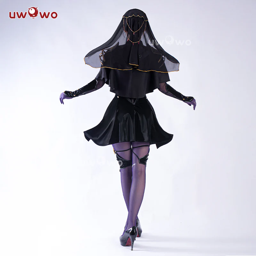

In [21]:
from google.colab import files

for mode in control_modes:
    if mode == chosen_mode:
        print(f"▶ 「{choice_name}」のお手本画像を選んでください（向いている画像：{image_hint}）")
    else:
        print(f"▶ 「{mode}」のお手本画像を選んでください")
    print("  サンプル画像のままにする場合は キャンセル")
    uploaded = files.upload()
    if not uploaded:
        print("  サンプル画像のままです")
        continue
    filename, data = next(iter(uploaded.items()))
    if len(uploaded) > 1:
        print(f"⚠️  複数選ばれたので、最初の {filename} だけ使います")

    save_path = os.path.join("./refer", mode + (os.path.splitext(filename)[1].lower() or ".png"))
    with open(save_path, "wb") as f:
        f.write(data)
    try:
        preview = Image.open(save_path).convert("RGB")
    except Exception:
        print(f"⚠️  {filename} は画像として読めないので、サンプル画像のままです")
        continue

    refer_images[mode] = save_path
    print(f"✅ お手本を {filename} に差し替えました")
    display(ImageOps.contain(preview, (256, 256)))

7. モデルのダウンロードと読み込み

やりたいことを選び直したり、設定を変えたりしたら、このセルからやり直すこと。

OutOfMemoryError: CUDA out of memory. というエラーが出た場合は、メニューから[ランタイム]-[セッションを再起動する]を行ったあと、「2. ファイルのダウンローダ」から実行し直す（ダウンロード済みのファイルはスキップされる）。

In [22]:
# 読み込み直す場合は、前のパイプラインを先に消してGPUメモリを空ける
if "pipe" in globals():
    del pipe
    clear_memory()

# ダウンロード（ダウンロード済みならスキップ）
model_path = download_model(model_url, path, use_original_filename=True, enable_resume=True)
for lora in loras:
    lora["path"] = download_model(lora["url"], path, use_original_filename=True, enable_resume=True)

# パイプラインのロード（ControlNet は Hugging Face から自動でダウンロードされる）
pipe = load_pipeline(model_path, control_modes=control_modes, loras=loras,
                     scheduler=scheduler, use_karras_sigmas=use_karras_sigmas)
print(type(pipe).__name__)

🧹 メモリをクリアしました
ファイル情報を確認中...
✅ ファイルが既に存在し、サイズが一致します: ./counterfeitV30_v30_pruned_fp16.safetensors
   ローカル: 4,244,124,028 bytes
   リモート: 4,244,124,028 bytes
ダウンロードをスキップします


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For

StableDiffusionControlNetPipeline


8. お手本から取り出す

お手本の画像から、まねる部分（ポーズ・輪郭線・立体感など）を取り出して表示する。
左がお手本、右が取り出したもの。右の画像に沿って絵が描かれる。

初回はポーズ・立体感を取り出すためのモデルがダウンロードされる。

左：お手本　右：ポーズ（棒人間のような骨格。これと同じ姿勢で描かれる）


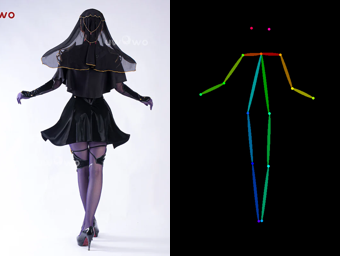

In [23]:
# 右の画像が何を表しているか
EXTRACTED = {
    "openpose": "ポーズ（棒人間のような骨格。これと同じ姿勢で描かれる）",
    "openpose_face": "ポーズ＋顔の向き",
    "openpose_faceonly": "顔の向き・表情",
    "openpose_full": "ポーズ＋顔＋手",
    "canny": "輪郭線（この線に沿って描かれる）",
    "depth": "立体感（白いほど手前、黒いほど奥）",
    "depth_zoe": "立体感（白いほど手前、黒いほど奥）",
    "tile": "お手本そのもの（この見た目に近く描き直される）",
    "blur": "ぼかしたお手本（大まかな色と配置が保たれる）",
    "lq": "ノイズを加えたお手本（大まかな見た目が保たれる）",
}

control_images = [prepare_control_image(mode, refer_images[mode], width, height) for mode in control_modes]

for mode, control_image in zip(control_modes, control_images):
    control_image.save(f"./outputs/control_{mode}.png")
    print(f"左：お手本　右：{EXTRACTED.get(mode, mode)}")
    display(make_grid([ImageOps.fit(load_image(refer_images[mode]).convert("RGB"), (width, height)), control_image]))

9. 画像生成

  0%|          | 0/28 [00:00<?, ?it/s]

生成時間: 36.6 秒


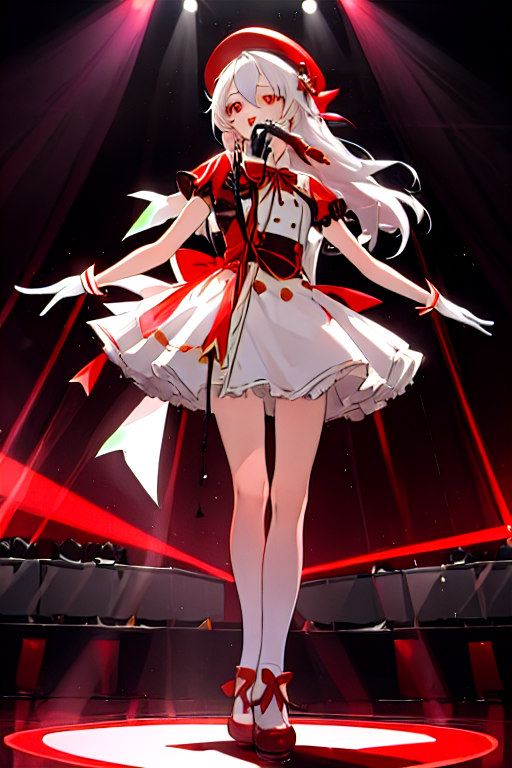

In [24]:
n = 1  # 生成する枚数。seed を1ずつ変えて生成する

for i in range(n):
    start = time.time()
    image = generate_image(pipe, prompt, negative_prompt,
                           control_images=control_images,
                           controlnet_conditioning_scale=controlnet_conditioning_scale,
                           loras=loras, seed=seed + i, steps=steps, guidance_scale=guidance_scale,
                           width=width, height=height)
    print(f"生成時間: {time.time() - start:.1f} 秒")
    image.save(f"./outputs/result_{i}.png")
    display(image)

以上。

（以下は発展的な内容。）

*   まねる部分の種類を細かく選ぶ・複数を同時に使う。
*   まねる強さ（効き具合）を変えて比較する。
*   生成の途中経過（latent）を画像にして見る。
*   生成した画像をまとめてダウンロードする。

# まねる部分の種類を細かく選ぶ・複数を同時に使う

「4. やりたいことを選ぶ」の4つ以外にも種類がある。control_mode という名前で指定する。

*   tile：お手本の見た目を保ったまま描き直す
*   blur / lq：ぼかした画像／ノイズを加えた画像から描き直す
*   canny：輪郭線
*   depth / depth_zoe：立体感（推定方法が MiDaS / ZoeDepth）
*   openpose / openpose_face / openpose_faceonly / openpose_full：ポーズ（顔・手を含めるかが違う）

複数並べると同時に使える（例：`["openpose", "depth"]`）。効き具合も同じ数・同じ順番で指定する。

下のセルを実行したあと、「7. モデルのダウンロードと読み込み」から順に実行し直す。
自分の画像を使う場合は、その前にアップロードのセルを実行し直す（モードごとにファイル選択が出る）。

In [11]:
control_modes = ["openpose", "depth"]
controlnet_conditioning_scale = [0.8, 0.5]

# まねる強さ（効き具合）を比較する

同じ seed で controlnet_conditioning_scale（まねる強さ）だけを変えて生成する。0.0 はお手本を使わないのと同じ。

controlnet_conditioning_scale = 0.0


  0%|          | 0/28 [00:00<?, ?it/s]

controlnet_conditioning_scale = 0.4


  0%|          | 0/28 [00:00<?, ?it/s]

controlnet_conditioning_scale = 0.8


  0%|          | 0/28 [00:00<?, ?it/s]

controlnet_conditioning_scale = 1.2


  0%|          | 0/28 [00:00<?, ?it/s]

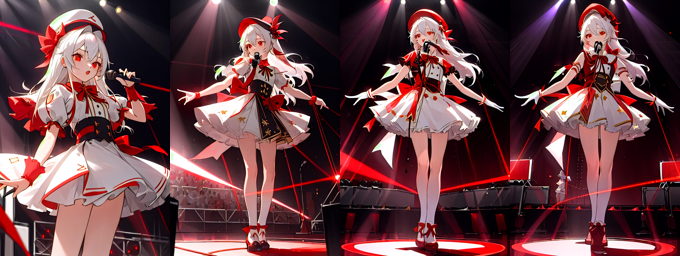

In [15]:
scales = [0.0, 0.4, 0.8, 1.2]
images = []
for scale in scales:
    print(f"controlnet_conditioning_scale = {scale}")
    images.append(generate_image(pipe, prompt, negative_prompt,
                                 control_images=control_images,
                                 controlnet_conditioning_scale=[scale] * len(control_images),
                                 loras=loras, seed=seed, steps=steps, guidance_scale=guidance_scale,
                                 width=width, height=height))
grid = make_grid(images)
grid.save("./outputs/compare_controlnet_scale.png")
display(grid)

# 生成の途中経過を見る

画像生成は、ノイズだけの latent（画像を 1/8 に圧縮した4チャンネルのデータ）から、ステップごとにノイズを取り除いていく処理。途中の latent を画像にして ./outputs に保存する。

* save_latent
  * "simple"：その時点の latent をそのまま画像にする
  * "overstep"：直前のステップからの変化がこのまま最後まで続くと仮定した到達点を画像にする
* latent_decoder
  * "vae"：VAE で復元する（正確だが遅い）
  * "approx"：係数を掛けて足すだけで色を出す（速いが粗い。サイズは 1/8）

  0%|          | 0/28 [00:00<?, ?it/s]

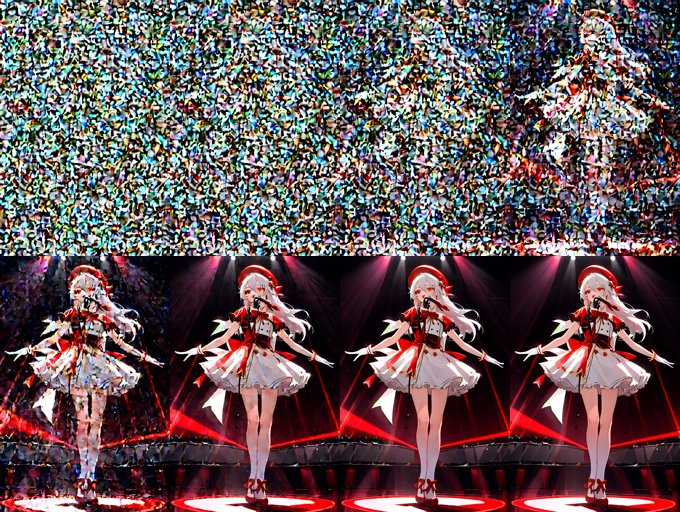

In [25]:
# 設定（control_modes・controlnet_conditioning_scale）を変えたのに「6.」「7.」を実行し直していないと数がずれるので、先に確認する
n = len(pipe.controlnet.nets) if isinstance(pipe, StableDiffusionControlNetPipeline) else 0
counts = [len(control_modes), n] + ([len(control_images), len(controlnet_conditioning_scale)] if n else [])
if len(set(counts)) != 1:
    raise ValueError(
        f"数が一致していない: control_modes={control_modes}, controlnet_conditioning_scale={controlnet_conditioning_scale}, "
        f"control_images={len(control_images)}枚, 読み込み済みのControlNet={n}個\n"
        "control_modes と controlnet_conditioning_scale を同じ数にして、「4. 設定」→「6.」→「7.」の順に実行し直すこと")

latent_images = []
image = generate_image(pipe, prompt, negative_prompt,
                       control_images=control_images,
                       controlnet_conditioning_scale=controlnet_conditioning_scale,
                       loras=loras, seed=seed, steps=steps, guidance_scale=guidance_scale,
                       width=width, height=height,
                       save_latent="simple", latent_decoder="vae", latent_images=latent_images)

# 4ステップおきに並べて表示
display(make_grid(latent_images[::4] + [image], cols=4))

# 生成した画像をまとめてダウンロードする

生成した画像は Colab のランタイムにしか残らない（ランタイムを切ると消える）。必要なら zip にしてダウンロードしておく。

In [26]:
!zip -r -q outputs.zip outputs
from google.colab import files
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>